<a href="https://colab.research.google.com/github/richaa357/Customer_churn_analysis/blob/main/Customer_churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df=pd.read_csv("/content/Telco_Customer_Churn_Dataset.csv")

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.shape

(7043, 21)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [38]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [39]:
df.drop("customerID",axis=1,inplace=True)

In [40]:
cat_cols=["gender","Partner","Dependents"	,"MultipleLines",	"InternetService"	,"OnlineSecurity","OnlineBackup","DeviceProtection"	,"TechSupport","StreamingTV","StreamingMovies",	"Contract","PaperlessBilling"	,"PaymentMethod"]

In [41]:
df=pd.get_dummies(df,columns=cat_cols,drop_first=True)

In [42]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)

In [43]:
df["PhoneService"]=df["PhoneService"].map({"Yes":1,"No":0})
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [44]:
X=df.drop("Churn",axis=1)
Y=df["Churn"]

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [30]:
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("Y_train",Y_test.shape)
print("Y_test",Y_test.shape)

X_train (5634, 30)
X_test (1409, 30)
Y_train (1409,)
Y_test (1409,)


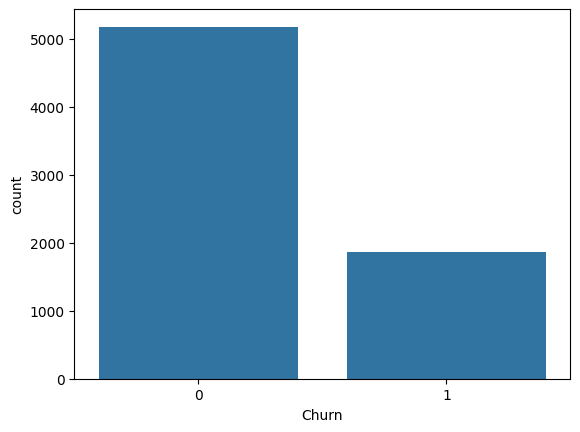

In [55]:
sns.countplot(data=df, x='Churn')
plt.show()

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Convert 'TotalCharges' to numeric, coercing errors to NaN and filling NaN with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Re-define X and Y from the cleaned df
X = df.drop("Churn", axis=1)
Y = df["Churn"]

# Re-split the data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [64]:
y_pred = model.predict(X_test)

In [66]:
print("Accuracy:",accuracy_score(Y_test, y_pred))

Accuracy: 0.8218594748048261


In [67]:
print(
    classification_report(
        Y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



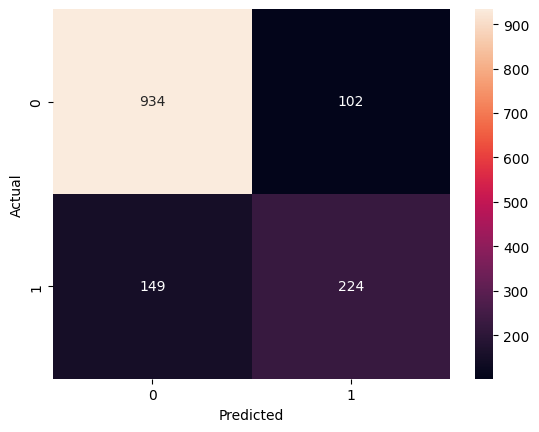

In [68]:
cm = confusion_matrix(Y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Absolute coefficient
feature_importance['Importance'] = (
    feature_importance['Coefficient'].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
25,Contract_Two year,-1.394747,1.394747
10,InternetService_Fiber optic,0.640943,0.640943
24,Contract_One year,-0.634564,0.634564
13,OnlineSecurity_Yes,-0.470118,0.470118
2,PhoneService,-0.441558,0.441558
19,TechSupport_Yes,-0.392280,0.392280
26,PaperlessBilling_Yes,0.336335,0.336335
28,PaymentMethod_Electronic check,0.326566,0.326566
8,MultipleLines_No phone service,0.276421,0.276421
23,StreamingMovies_Yes,0.226465,0.226465


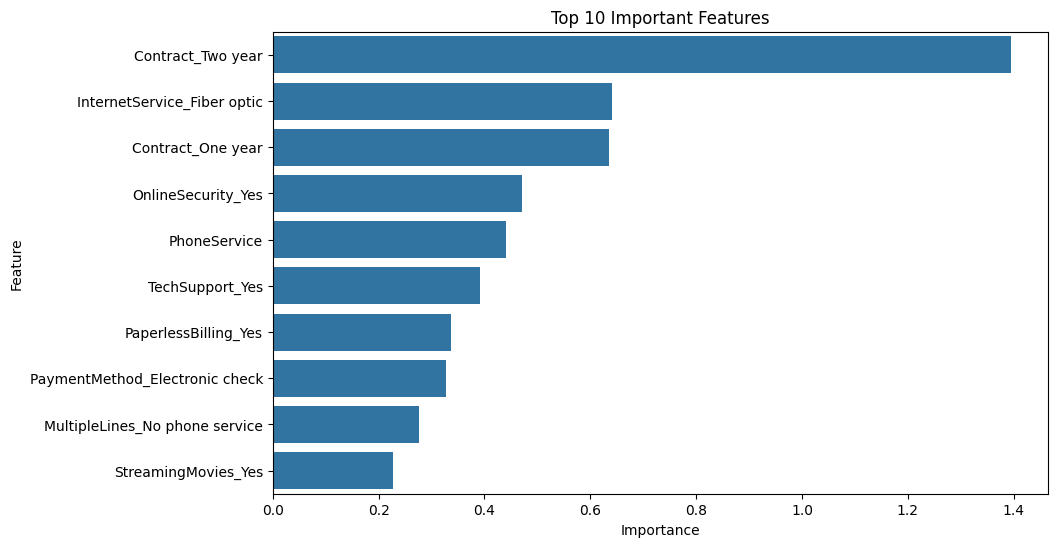

In [70]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

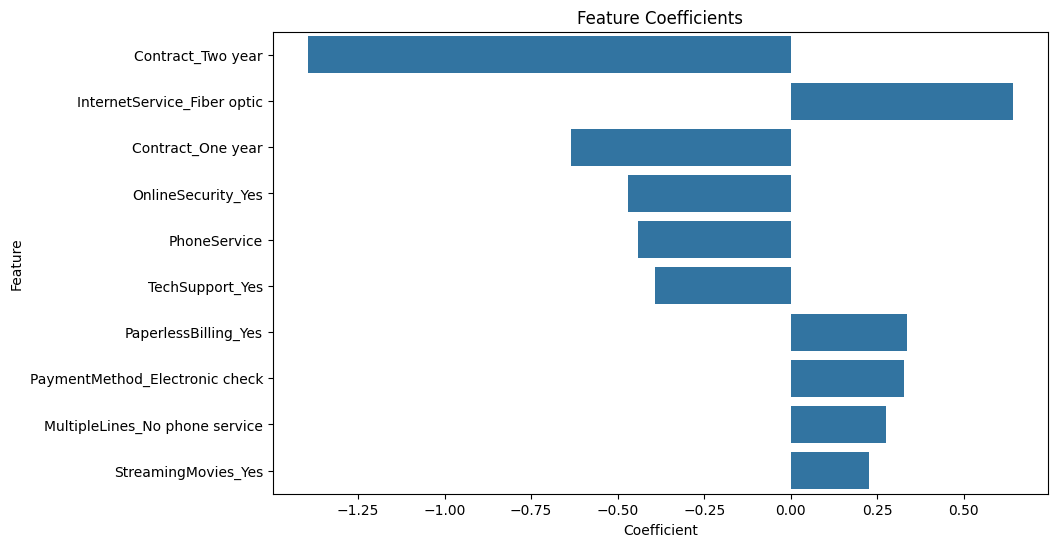

In [71]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Feature Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

## 16. Conclusion

In this project, customer churn was analyzed using the Telco Customer Churn dataset.

The dataset was first cleaned by removing unnecessary attributes, handling missing values, converting numerical and categorical features, and performing exploratory data analysis.

Logistic Regression was then trained to predict whether a customer would churn.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

Feature importance analysis was also performed using Logistic Regression coefficients to identify the features that had the strongest influence on the model's predictions.

Overall, this project helped demonstrate the complete Machine Learning workflow:

Data Understanding → Data Cleaning → EDA → Feature Engineering →
Encoding → Train-Test Split → Scaling → Model Training →
Evaluation → Feature Importance